In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M5.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Study configuration (same as 06a) ─────────────────────────────────────────
ATR_WINDOW    = 20
SESSION_START = 12
SESSION_END   = 16
SPLIT_DATE    = pd.Timestamp('2024-03-07', tz='UTC')  # holdout untouched
THRESHOLDS    = [1.0, 1.5, 2.0, 2.5]
FWD_HORIZONS  = [1, 3, 5, 10, 20]
MAX_HORIZON   = 20

print('Cell 1 OK — Exp 06a.1: VWAP Dynamics Decomposition')
print('Two questions:')
print('  1. Decompose gap_reduction → price_component vs vwap_drift_component')
print('  2. Bifurcation: small deviation=mean reversion, large deviation=continuation?')
print('TRAIN ONLY — holdout untouched')

Cell 1 OK — Exp 06a.1: VWAP Dynamics Decomposition
Two questions:
  1. Decompose gap_reduction → price_component vs vwap_drift_component
  2. Bifurcation: small deviation=mean reversion, large deviation=continuation?
TRAIN ONLY — holdout untouched


In [2]:
# ── Load data + True Range ATR ─────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_FILE)
df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)
df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)
df_raw['date'] = df_raw['open_time'].dt.date

prev_close    = df_raw['close'].shift(1)
df_raw['tr']  = np.maximum(
    df_raw['high'] - df_raw['low'],
    np.maximum((df_raw['high'] - prev_close).abs(), (df_raw['low'] - prev_close).abs())
)
df_raw['atr'] = df_raw['tr'].rolling(ATR_WINDOW, min_periods=ATR_WINDOW // 2).mean()
print(f'Loaded: {len(df_raw):,} M5 candles  |  ATR median: {df_raw["atr"].median():.2f} USDT')
print('Cell 2 OK')

Loaded: 777,263 M5 candles  |  ATR median: 65.70 USDT
Cell 2 OK


In [3]:
# ── Session data + VWAP + forward columns ─────────────────────────────────────

sess_mask = (
    (df_raw['open_time'].dt.hour >= SESSION_START) &
    (df_raw['open_time'].dt.hour <  SESSION_END)
)
df = df_raw[sess_mask].copy().reset_index(drop=True)
df['session_candle_num'] = df.groupby('date').cumcount()

# Session VWAP: typical_price = (H+L+C)/3, cumulative from session open
df['typical_price'] = (df['high'] + df['low'] + df['close']) / 3.0
df['_tp_vol']       = df['typical_price'] * df['volume']
df['vwap']          = df.groupby('date')['_tp_vol'].cumsum() / df.groupby('date')['volume'].cumsum()
df.drop(columns=['_tp_vol'], inplace=True)

# Current deviation
df['dev_raw'] = df['close'] - df['vwap']          # USDT distance (signed)
df['dev_atr'] = df['dev_raw'] / df['atr']         # ATR-normalized
df['abs_dev_atr'] = df['dev_atr'].abs()
df['direction_sign'] = np.sign(df['dev_atr'])      # +1 = above VWAP, -1 = below

# Forward close and VWAP at each horizon (within-session, cross-day = NaN)
print(f'Computing forward close and VWAP columns (1..{MAX_HORIZON})...')
for h in range(1, MAX_HORIZON + 1):
    df[f'fwd_close_{h}c'] = df.groupby('date')['close'].shift(-h)
    df[f'fwd_vwap_{h}c']  = df.groupby('date')['vwap'].shift(-h)

print(f'Session candles: {len(df):,}  |  Dates: {df["date"].nunique():,}')
print('Cell 3 OK')

Computing forward close and VWAP columns (1..20)...
Session candles: 129,594  |  Dates: 2,701
Cell 3 OK


In [4]:
# ── Train filter ───────────────────────────────────────────────────────────────
df['split'] = 'holdout'
df.loc[df['open_time'] < SPLIT_DATE, 'split'] = 'train'
train = df[df['split'] == 'train'].copy()

n_days = train['date'].nunique()
print(f'TRAIN: {len(train):,} session candles | {n_days:,} days')
print(f'       {train["open_time"].iloc[0].date()} → {train["open_time"].iloc[-1].date()}')

print(f'\nThreshold event counts (train):')
for T in THRESHOLDS:
    n = (train['abs_dev_atr'] > T).sum()
    print(f'  |dev_atr| > {T:.1f}: {n:,}  ({n/n_days:.1f}/day)')
print('Cell 4 OK')

TRAIN: 90,714 session candles | 1,891 days
       2019-01-01 → 2024-03-06

Threshold event counts (train):
  |dev_atr| > 1.0: 40,596  (21.5/day)
  |dev_atr| > 1.5: 25,126  (13.3/day)
  |dev_atr| > 2.0: 14,790  (7.8/day)
  |dev_atr| > 2.5: 8,348  (4.4/day)
Cell 4 OK


In [5]:
# ── VWAP drift decomposition ──────────────────────────────────────────────────
#
# For an event at time t (e.g., price above VWAP), at horizon t+N:
#
#   gap_t  = close_t  - vwap_t     (positive if above VWAP)
#   gap_tN = close_tN - vwap_tN    (positive if still above VWAP at t+N)
#
#   gap_reduction = gap_t - gap_tN   (positive = gap shrank = partial reversion)
#
# Decomposition:
#   gap_reduction = (close_t - close_tN) + (vwap_tN - vwap_t)
#                 = price_component + vwap_component
#
# Where:
#   price_component = close_t - close_tN  [>0 = price DROPPED toward VWAP for SHORT]
#   vwap_component  = vwap_tN - vwap_t    [>0 = VWAP ROSE toward price for SHORT]
#
# For LONG (below VWAP), direction flips:
#   gap_reduction = (close_tN - close_t) + (vwap_t - vwap_tN)
#
# Unified with direction_sign (+1 for SHORT, -1 for LONG):
#   price_component = direction_sign * (close_t - close_tN)
#   vwap_component  = direction_sign * (vwap_tN - vwap_t)
#   gap_reduction   = price_component + vwap_component
#
# Fraction from VWAP drift: vwap_component / gap_reduction  (when gap_reduction > 0)

decomp_rows = []

for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T].copy()
    for N in FWD_HORIZONS:
        fc  = f'fwd_close_{N}c'
        fv  = f'fwd_vwap_{N}c'
        sub = ev.dropna(subset=[fc, fv])
        if len(sub) < 20: continue

        d_sign = sub['direction_sign']

        price_comp = d_sign * (sub['close'] - sub[fc])      # >0 = price moved toward VWAP
        vwap_comp  = d_sign * (sub[fv]     - sub['vwap'])   # >0 = VWAP moved toward price
        gap_red    = price_comp + vwap_comp                  # total gap reduction

        # Only use events where gap actually reduced (positive reversion)
        rev_mask = gap_red > 0
        n_rev    = rev_mask.sum()

        decomp_rows.append({
            'threshold':          T,
            'horizon':            N,
            'n_events':           len(sub),
            'n_reverted':         int(n_rev),
            'pct_reverted':       round(n_rev / len(sub) * 100, 1),
            # Mean components (ALL events, signed — including non-reversions)
            'mean_price_comp_pct': round(price_comp.mean() * 100, 5),
            'mean_vwap_comp_pct':  round(vwap_comp.mean()  * 100, 5),
            'mean_gap_red_pct':    round(gap_red.mean()    * 100, 5),
            # Among events that DID revert: fraction from VWAP drift
            'vwap_fraction_of_reversion': round(
                (vwap_comp[rev_mask] / gap_red[rev_mask]).mean(), 4
            ) if n_rev > 0 else float('nan'),
            'price_fraction_of_reversion': round(
                (price_comp[rev_mask] / gap_red[rev_mask]).mean(), 4
            ) if n_rev > 0 else float('nan'),
        })

ddf = pd.DataFrame(decomp_rows)

print('VWAP drift decomposition — train only')
print('='*70)
print('Mean gap reduction components (% of price, ALL events):')
print(f'{"T":>4}  {"N":>4}  {"n":>6}  {"price_comp%":>12}  {"vwap_comp%":>11}  {"gap_red%":>9}')
for _, row in ddf.iterrows():
    print(f'{row["threshold"]:>4.1f}  {row["horizon"]:>4}  {row["n_events"]:>6}'
          f'  {row["mean_price_comp_pct"]:>+12.5f}  {row["mean_vwap_comp_pct"]:>+11.5f}'
          f'  {row["mean_gap_red_pct"]:>+9.5f}')

print()
print('Among events that DID revert: fraction explained by VWAP drift:')
print(f'{"T":>4}  {"N":>4}  {"n_rev":>6}  {"vwap_frac":>10}  {"price_frac":>11}')
for _, row in ddf.iterrows():
    print(f'{row["threshold"]:>4.1f}  {row["horizon"]:>4}  {int(row["n_reverted"]):>6}'
          f'  {row["vwap_fraction_of_reversion"]:>10.4f}  {row["price_fraction_of_reversion"]:>11.4f}')

ddf.to_csv(OUTPUT_DIR / '06a1_decomposition.csv', index=False)
print('\nSaved: 06a1_decomposition.csv')
print('Cell 5 OK')

VWAP drift decomposition — train only
Mean gap reduction components (% of price, ALL events):
   T     N       n   price_comp%   vwap_comp%   gap_red%
 1.0   1.0  39383.0      +2.73438   +912.41573  +915.15011
 1.0   3.0  36995.0     +73.53994  +2339.51611  +2413.05605
 1.0   5.0  34646.0    +175.43598  +3476.08867  +3651.52465
 1.0  10.0  29041.0    +383.68758  +5537.57323  +5921.26081
 1.0  20.0  18704.0   +1207.65419  +7437.40656  +8645.06075
 1.5   1.0  24179.0     +45.58894  +1129.92516  +1175.51411
 1.5   3.0  22399.0    +100.10045  +2896.55663  +2996.65708
 1.5   5.0  20679.0    +121.42613  +4324.69744  +4446.12357
 1.5  10.0  16693.0    +245.45636  +7010.63282  +7256.08918
 1.5  20.0  9731.0   +1310.69407  +9629.39260  +10940.08667
 2.0   1.0  14119.0     +46.78051  +1400.90910  +1447.68960
 2.0   3.0  12836.0     +66.91399  +3579.23293  +3646.14693
 2.0   5.0  11683.0     +73.35590  +5343.32312  +5416.67902
 2.0  10.0  9034.0    -128.51096  +8763.36313  +8634.85218
 2.0  20.0 

In [6]:
# ── Conditional continuation vs reversion by threshold ────────────────────────
# After |dev_atr| > T, does the gap GROW or SHRINK at horizon N?
# P(continuation) = P(|gap_tN| > |gap_t|) = gap got WORSE
# P(reversion)    = P(|gap_tN| < |gap_t|) = gap got BETTER

print('Conditional continuation study (train only)')
print('P(deviation grew) = P(continuation)  |  P(deviation shrank) = P(reversion)')
print()

cont_rows = []
for T in THRESHOLDS:
    ev = train[train['abs_dev_atr'] > T].copy()
    row = {'threshold': T, 'n': len(ev)}

    for N in FWD_HORIZONS:
        fc = f'fwd_close_{N}c'
        fv = f'fwd_vwap_{N}c'
        sub = ev.dropna(subset=[fc, fv])
        if len(sub) < 10: continue

        # Future gap (signed, in USDT)
        fwd_dev_raw = sub[fc] - sub[fv]
        cur_dev_raw = sub['dev_raw']

        # Continuation: absolute gap GREW (deviation got larger)
        continuation = (fwd_dev_raw.abs() > cur_dev_raw.abs())

        # Cross-over: price crossed VWAP
        crossed = (fwd_dev_raw * cur_dev_raw < 0)  # sign flipped = crossed

        row[f'p_cont_{N}c']    = round(continuation.mean() * 100, 1)
        row[f'p_cross_{N}c']   = round(crossed.mean()       * 100, 1)
        row[f'p_part_rev_{N}c']= round((~continuation & ~crossed).mean() * 100, 1)

        # Mean future dev_atr (normalized by current ATR for comparability)
        # Positive: same direction as entry. Negative: crossed.
        cur_dev_sign_preserved = (cur_dev_raw * fwd_dev_raw > 0)  # same sign
        row[f'mean_fwd_dev_pct_{N}c'] = round(fwd_dev_raw.mean() / cur_dev_raw.abs().mean(), 4)

    cont_rows.append(row)

cdf = pd.DataFrame(cont_rows)

print('P(continuation) — gap grew at horizon N:')
cont_cols = ['threshold', 'n'] + [f'p_cont_{N}c' for N in FWD_HORIZONS]
print(cdf[cont_cols].to_string(index=False))
print()
print('P(crossed VWAP) — deviation sign flipped at horizon N:')
cross_cols = ['threshold', 'n'] + [f'p_cross_{N}c' for N in FWD_HORIZONS]
print(cdf[cross_cols].to_string(index=False))
print()
print('P(partial reversion, no cross) — closer but not past VWAP:')
rev_cols = ['threshold', 'n'] + [f'p_part_rev_{N}c' for N in FWD_HORIZONS]
print(cdf[rev_cols].to_string(index=False))
print()
print('Mean future dev / current dev  (1.0=same gap, >1=grew, <1=shrank, <0=crossed):')
mean_cols = ['threshold', 'n'] + [f'mean_fwd_dev_pct_{N}c' for N in FWD_HORIZONS]
print(cdf[mean_cols].to_string(index=False))

cdf.to_csv(OUTPUT_DIR / '06a1_continuation.csv', index=False)
print('\nSaved: 06a1_continuation.csv')
print('Cell 6 OK')

Conditional continuation study (train only)
P(deviation grew) = P(continuation)  |  P(deviation shrank) = P(reversion)

P(continuation) — gap grew at horizon N:
 threshold     n  p_cont_1c  p_cont_3c  p_cont_5c  p_cont_10c  p_cont_20c
       1.0 40596       41.3       37.5       36.5        37.2        43.9
       1.5 25126       39.8       34.9       32.8        31.5        36.2
       2.0 14790       38.2       32.8       30.5        27.7        31.2
       2.5  8348       37.1       30.7       28.0        24.9        27.4

P(crossed VWAP) — deviation sign flipped at horizon N:
 threshold     n  p_cross_1c  p_cross_3c  p_cross_5c  p_cross_10c  p_cross_20c
       1.0 40596         2.1         8.9        14.8         25.0         38.0
       1.5 25126         1.1         5.5        10.1         20.0         34.4
       2.0 14790         0.8         3.9         7.6         16.0         31.7
       2.5  8348         0.6         3.0         6.1         13.4         28.9

P(partial reversi

In [7]:
# ── Bifurcation analysis ──────────────────────────────────────────────────────
# Key question: is there a threshold where behavior flips from mean-reversion to continuation?
#
# Method: bin |dev_atr| into deciles, compute P(continuation at 5c) for each bin.
# If P(cont) < 50% at small |dev_atr| and > 50% at large |dev_atr| → bifurcation confirmed.
#
# Bifurcation hypothesis (from 06a finding: P(rev50,10c) decreases with T):
#   Small dislocation → noise → reverts
#   Large dislocation → informed flow → continues

print('Bifurcation analysis — P(continuation at 5c) vs |dev_atr| bin (train)')
print()

# Use N=5 horizon for bifurcation analysis
N_BIF = 5
fc_bif = f'fwd_close_{N_BIF}c'
fv_bif = f'fwd_vwap_{N_BIF}c'

bif_data = train.dropna(subset=[fc_bif, fv_bif, 'dev_raw']).copy()
bif_data = bif_data[bif_data['abs_dev_atr'] > 0.2].copy()  # exclude near-VWAP noise

# Compute continuation
fwd_dev_raw_bif = bif_data[fc_bif] - bif_data[fv_bif]
bif_data['continuation'] = (fwd_dev_raw_bif.abs() > bif_data['dev_raw'].abs())

# Bin by |dev_atr|
N_BINS = 20
bif_data['dev_bin'] = pd.qcut(bif_data['abs_dev_atr'], q=N_BINS, duplicates='drop')

bif_agg = bif_data.groupby('dev_bin', observed=True).agg(
    n=('continuation', 'count'),
    p_cont=('continuation', 'mean'),
    dev_atr_mean=('abs_dev_atr', 'mean'),
    dev_atr_mid=('abs_dev_atr', 'median'),
).reset_index()
bif_agg['p_cont_pct'] = bif_agg['p_cont'] * 100

print(f'|dev_atr| bins (quantile, N={N_BINS}) vs P(continuation at {N_BIF}c):')
print(f'{"bin_mid":>8}  {"n":>5}  {"P(cont)%":>9}')
for _, row in bif_agg.iterrows():
    marker = '  ← >50% CONTINUES' if row['p_cont_pct'] > 50 else ''
    print(f'{row["dev_atr_mid"]:>8.3f}  {int(row["n"]):>5}  {row["p_cont_pct"]:>9.1f}%{marker}')

# Find crossover point (where P(cont) crosses 50%)
below_50 = bif_agg[bif_agg['p_cont_pct'] <= 50]
above_50 = bif_agg[bif_agg['p_cont_pct'] >  50]
if len(below_50) > 0 and len(above_50) > 0:
    crossover = bif_agg.iloc[bif_agg['p_cont_pct'].sub(50).abs().idxmin()]
    print(f'\nApproximate bifurcation point: |dev_atr| ≈ {crossover["dev_atr_mid"]:.3f}')
else:
    print('\nNo clear crossover at 50% found — check visualization.')

# Statistical test: is P(cont) significantly different across low vs high dev?
low_dev  = bif_data[bif_data['abs_dev_atr'] < bif_data['abs_dev_atr'].median()]
high_dev = bif_data[bif_data['abs_dev_atr'] >= bif_data['abs_dev_atr'].median()]
chi2, pval, _, _ = stats.chi2_contingency([
    [low_dev['continuation'].sum(),  (~low_dev['continuation']).sum()],
    [high_dev['continuation'].sum(), (~high_dev['continuation']).sum()],
])
print(f'\nChi-square test (low vs high |dev_atr|, continuation rate):')
print(f'  Low  median:  P(cont)={low_dev["continuation"].mean()*100:.1f}%  n={len(low_dev):,}')
print(f'  High median:  P(cont)={high_dev["continuation"].mean()*100:.1f}%  n={len(high_dev):,}')
print(f'  chi2={chi2:.2f}  p={pval:.6f}  {"*** (p<0.05)" if pval < 0.05 else "ns"}')

bif_agg.to_csv(OUTPUT_DIR / '06a1_bifurcation.csv', index=False)
print('\nSaved: 06a1_bifurcation.csv')
print('Cell 7 OK')

Bifurcation analysis — P(continuation at 5c) vs |dev_atr| bin (train)

|dev_atr| bins (quantile, N=20) vs P(continuation at 5c):
 bin_mid      n   P(cont)%
   0.233   3527       83.1%  ← >50% CONTINUES
   0.299   3526       77.7%  ← >50% CONTINUES
   0.366   3526       73.8%  ← >50% CONTINUES
   0.436   3526       69.0%  ← >50% CONTINUES
   0.509   3526       64.0%  ← >50% CONTINUES
   0.585   3526       59.8%  ← >50% CONTINUES
   0.663   3526       57.1%  ← >50% CONTINUES
   0.747   3526       53.9%  ← >50% CONTINUES
   0.837   3526       50.7%  ← >50% CONTINUES
   0.934   3526       48.3%
   1.035   3526       43.6%
   1.146   3526       43.4%
   1.268   3526       41.2%
   1.404   3526       39.8%
   1.558   3526       38.0%
   1.740   3526       35.5%
   1.954   3526       34.2%
   2.234   3526       33.5%
   2.634   3526       30.4%
   3.427   3526       26.3%

Approximate bifurcation point: |dev_atr| ≈ 0.837

Chi-square test (low vs high |dev_atr|, continuation rate):
  Low  medi

In [8]:
# ── Additional: direction asymmetry ───────────────────────────────────────────
# Do LONG events (below VWAP) behave differently from SHORT events (above VWAP)?
# Hypothesis: in a trending session, one direction dominates.

print('Direction asymmetry: above-VWAP (SHORT setup) vs below-VWAP (LONG setup)')
print()

T_REF = 2.0
N_REF = 5
fc_ref = f'fwd_close_{N_REF}c'
fv_ref = f'fwd_vwap_{N_REF}c'

for direction, dname in [(+1, 'SHORT (above VWAP)'), (-1, 'LONG (below VWAP)')]:
    ev = train[
        (train['abs_dev_atr'] > T_REF) &
        (train['direction_sign'] == direction)
    ].dropna(subset=[fc_ref, fv_ref, 'dev_raw'])
    if len(ev) < 10: continue

    fwd_dev = ev[fc_ref] - ev[fv_ref]
    cont = (fwd_dev.abs() > ev['dev_raw'].abs())
    cross = (fwd_dev * ev['dev_raw'] < 0)

    price_comp = direction * (ev['close'] - ev[fc_ref])
    vwap_comp  = direction * (ev[fv_ref]  - ev['vwap'])
    gap_red    = price_comp + vwap_comp
    rev_mask   = gap_red > 0

    print(f'{dname}  (|dev_atr|>{T_REF}, n={len(ev):,}):')
    print(f'  P(continuation, {N_REF}c):  {cont.mean()*100:.1f}%')
    print(f'  P(cross VWAP,  {N_REF}c):  {cross.mean()*100:.1f}%')
    print(f'  Mean price comp:  {price_comp.mean()*100:+.5f}%')
    print(f'  Mean VWAP comp:   {vwap_comp.mean()*100:+.5f}%')
    if rev_mask.sum() > 0:
        vf = (vwap_comp[rev_mask] / gap_red[rev_mask]).mean()
        pf = (price_comp[rev_mask] / gap_red[rev_mask]).mean()
        print(f'  Among reversions: VWAP fraction={vf:.3f}  price fraction={pf:.3f}')
    print()

# Yearly pattern: is bifurcation stable across years?
print('Yearly P(continuation at 5c) for |dev_atr| > 2.0 (train only):')
train['year'] = train['open_time'].dt.year
ev_all = train[train['abs_dev_atr'] > 2.0].dropna(subset=[fc_ref, fv_ref, 'dev_raw']).copy()
fwd_dev_all = ev_all[fc_ref] - ev_all[fv_ref]
ev_all['cont'] = (fwd_dev_all.abs() > ev_all['dev_raw'].abs())
year_agg = ev_all.groupby('year')['cont'].agg(n='count', p_cont='mean')
year_agg['p_cont_pct'] = year_agg['p_cont'] * 100
print(year_agg.to_string())
print('Cell 8 OK')

Direction asymmetry: above-VWAP (SHORT setup) vs below-VWAP (LONG setup)

SHORT (above VWAP)  (|dev_atr|>2.0, n=6,551):
  P(continuation, 5c):  31.5%
  P(cross VWAP,  5c):  7.6%
  Mean price comp:  -130.11159%
  Mean VWAP comp:   +5028.07183%
  Among reversions: VWAP fraction=3.480  price fraction=-2.480

LONG (below VWAP)  (|dev_atr|>2.0, n=5,132):
  P(continuation, 5c):  29.3%
  P(cross VWAP,  5c):  7.6%
  Mean price comp:  +333.08223%
  Mean VWAP comp:   +5745.74150%
  Among reversions: VWAP fraction=1.666  price fraction=-0.666

Yearly P(continuation at 5c) for |dev_atr| > 2.0 (train only):
         n    p_cont  p_cont_pct
year                            
2019  1647  0.272010   27.200971
2020  2094  0.282235   28.223496
2021  2568  0.326324   32.632399
2022  2315  0.319222   31.922246
2023  2595  0.309056   30.905588
2024   464  0.316810   31.681034
Cell 8 OK


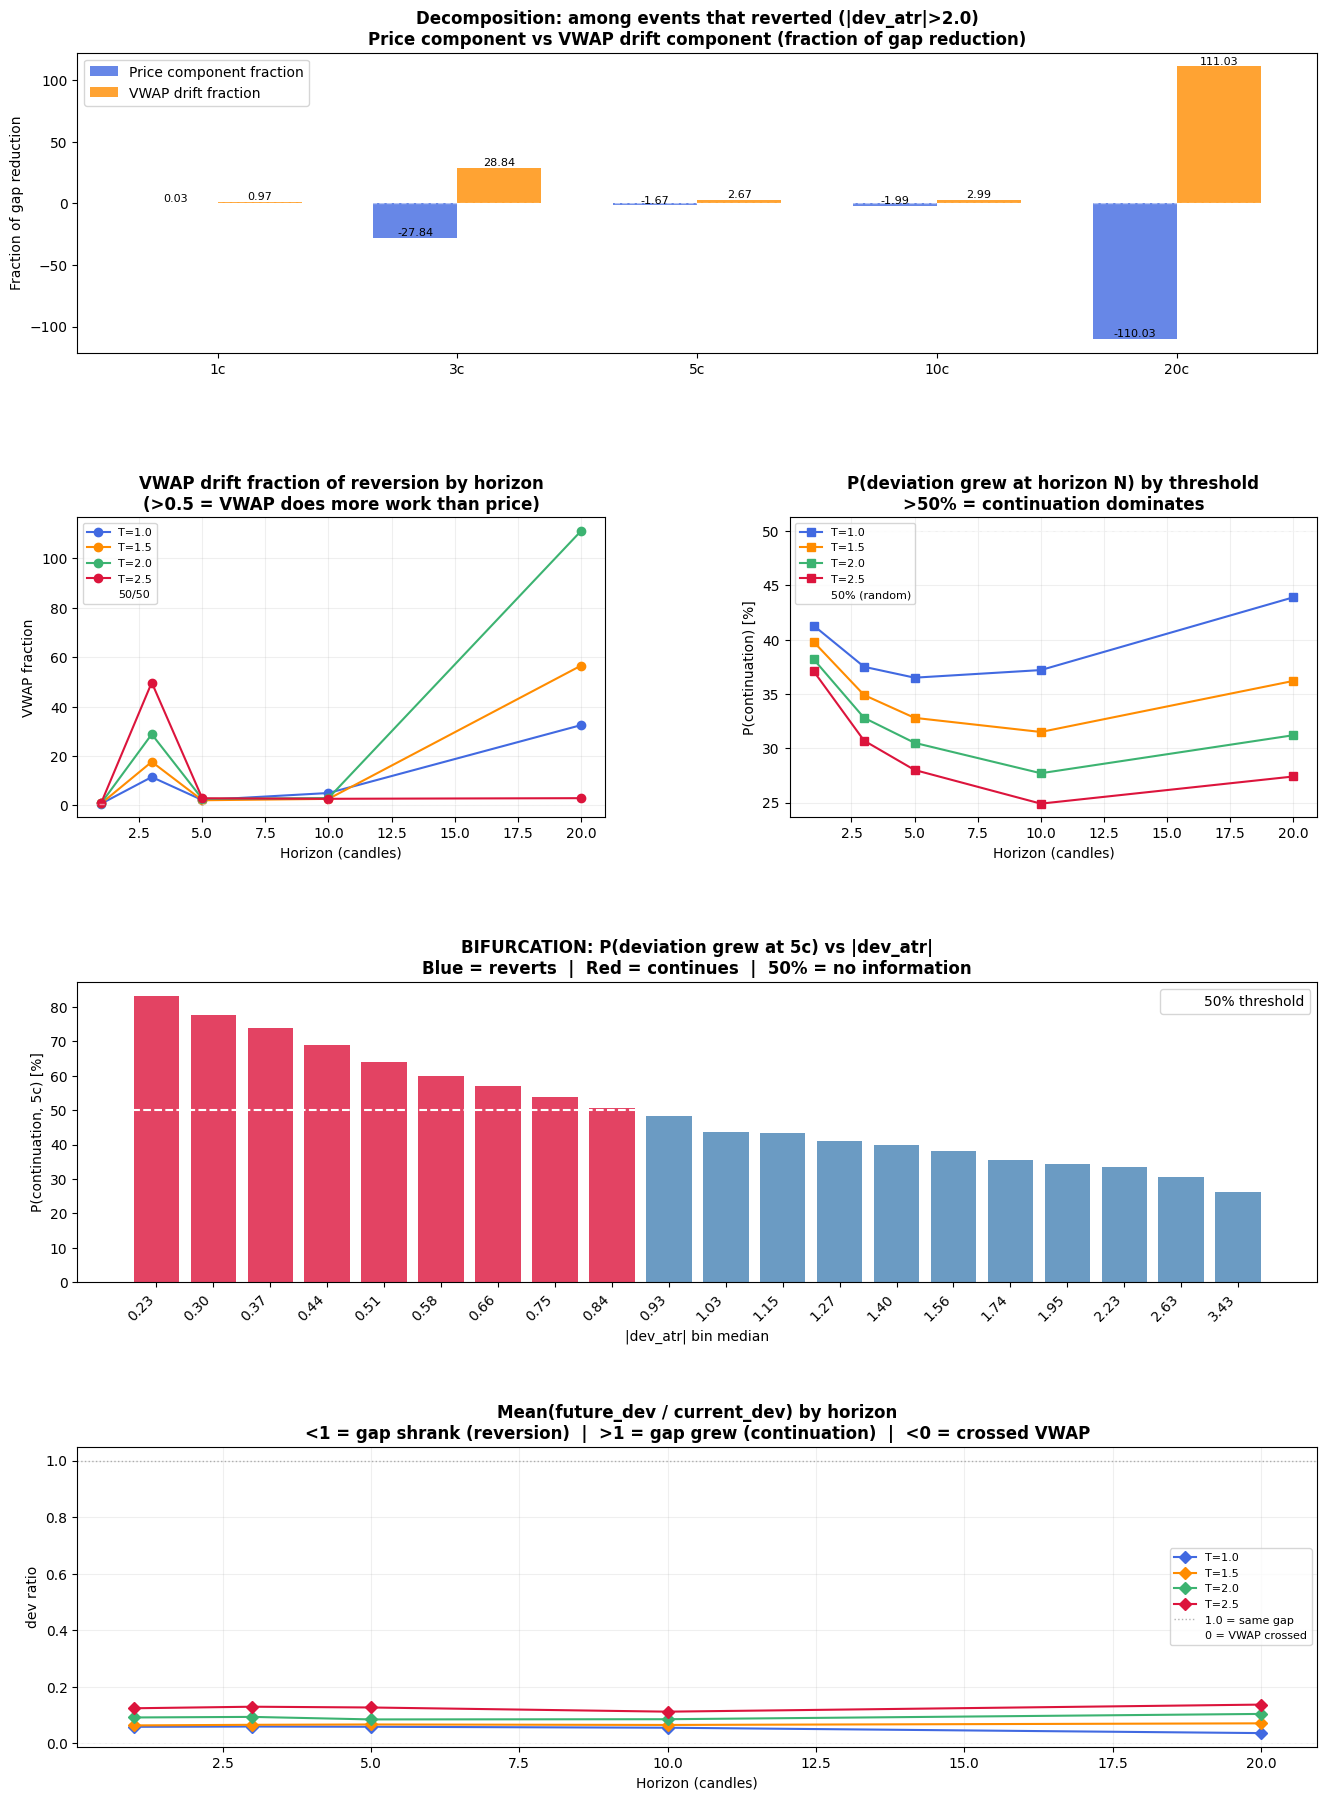

Saved: 06a1_visualizations.png
Cell 9 OK


In [9]:
# ── Visualizations ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 22))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# 1. Decomposition: price vs VWAP fraction by horizon (for T=2.0)
ax1 = fig.add_subplot(gs[0, :])
T_plot = 2.0
sub_d  = ddf[ddf['threshold'] == T_plot].copy()
if len(sub_d) > 0:
    h_vals = sub_d['horizon'].values
    price_f = sub_d['price_fraction_of_reversion'].values
    vwap_f  = sub_d['vwap_fraction_of_reversion'].values
    x = np.arange(len(h_vals))
    w = 0.35
    bars1 = ax1.bar(x - w/2, price_f, w, label='Price component fraction', color='royalblue', alpha=0.8)
    bars2 = ax1.bar(x + w/2, vwap_f,  w, label='VWAP drift fraction',     color='darkorange', alpha=0.8)
    ax1.axhline(0.5, color='white', ls='--', lw=1, alpha=0.5)
    ax1.set_xticks(x); ax1.set_xticklabels([f'{h}c' for h in h_vals])
    ax1.set_title(f'Decomposition: among events that reverted (|dev_atr|>{T_plot})\n'
                  'Price component vs VWAP drift component (fraction of gap reduction)',
                  fontweight='bold')
    ax1.set_ylabel('Fraction of gap reduction'); ax1.legend()
    for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# 2. VWAP fraction of reversion by threshold and horizon
ax2 = fig.add_subplot(gs[1, 0])
colors = ['royalblue', 'darkorange', 'mediumseagreen', 'crimson']
for i, T in enumerate(THRESHOLDS):
    sub_d = ddf[ddf['threshold'] == T].dropna(subset=['vwap_fraction_of_reversion'])
    if len(sub_d) == 0: continue
    ax2.plot(sub_d['horizon'], sub_d['vwap_fraction_of_reversion'],
             marker='o', color=colors[i], label=f'T={T}')
ax2.axhline(0.5, color='white', ls='--', lw=1, alpha=0.5, label='50/50')
ax2.set_title('VWAP drift fraction of reversion by horizon\n(>0.5 = VWAP does more work than price)',
              fontweight='bold')
ax2.set_xlabel('Horizon (candles)'); ax2.set_ylabel('VWAP fraction')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

# 3. P(continuation) by threshold and horizon
ax3 = fig.add_subplot(gs[1, 1])
for i, T in enumerate(THRESHOLDS):
    row = cdf[cdf['threshold'] == T]
    if len(row) == 0: continue
    row = row.iloc[0]
    y_vals = [row.get(f'p_cont_{N}c', float('nan')) for N in FWD_HORIZONS]
    ax3.plot(FWD_HORIZONS, y_vals, marker='s', color=colors[i], label=f'T={T}')
ax3.axhline(50, color='white', ls='--', lw=1, alpha=0.5, label='50% (random)')
ax3.set_title('P(deviation grew at horizon N) by threshold\n>50% = continuation dominates',
              fontweight='bold')
ax3.set_xlabel('Horizon (candles)'); ax3.set_ylabel('P(continuation) [%]')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)

# 4. Bifurcation: P(continuation at 5c) vs |dev_atr| bins
ax4 = fig.add_subplot(gs[2, :])
if len(bif_agg) > 0:
    ax4.bar(range(len(bif_agg)), bif_agg['p_cont_pct'],
            color=np.where(bif_agg['p_cont_pct'] > 50, 'crimson', 'steelblue'), alpha=0.8)
    ax4.axhline(50, color='white', ls='--', lw=1.5, label='50% threshold')
    ax4.set_xticks(range(len(bif_agg)))
    ax4.set_xticklabels([f'{v:.2f}' for v in bif_agg['dev_atr_mid']], rotation=45, ha='right')
    ax4.set_xlabel('|dev_atr| bin median'); ax4.set_ylabel('P(continuation, 5c) [%]')
    ax4.set_title('BIFURCATION: P(deviation grew at 5c) vs |dev_atr|\n'
                  'Blue = reverts  |  Red = continues  |  50% = no information',
                  fontweight='bold')
    ax4.legend()

# 5. Mean future dev / current dev (ratio) by threshold and horizon
ax5 = fig.add_subplot(gs[3, :])
for i, T in enumerate(THRESHOLDS):
    row = cdf[cdf['threshold'] == T]
    if len(row) == 0: continue
    row = row.iloc[0]
    y_vals = [row.get(f'mean_fwd_dev_pct_{N}c', float('nan')) for N in FWD_HORIZONS]
    ax5.plot(FWD_HORIZONS, y_vals, marker='D', color=colors[i], label=f'T={T}')
ax5.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.6, label='1.0 = same gap')
ax5.axhline(0.0, color='white', ls='--', lw=0.8, alpha=0.5, label='0 = VWAP crossed')
ax5.set_title('Mean(future_dev / current_dev) by horizon\n'
              '<1 = gap shrank (reversion)  |  >1 = gap grew (continuation)  |  <0 = crossed VWAP',
              fontweight='bold')
ax5.set_xlabel('Horizon (candles)'); ax5.set_ylabel('dev ratio')
ax5.legend(fontsize=8); ax5.grid(alpha=0.2)

plt.savefig(OUTPUT_DIR / '06a1_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 06a1_visualizations.png')
print('Cell 9 OK')

In [10]:
# ── Summary: key findings ──────────────────────────────────────────────────────

SEP = '='*65
print(SEP)
print('  EXP 06a.1 — VWAP DYNAMICS DECOMPOSITION SUMMARY')
print(SEP)
print()
print('QUESTION 1: How much of the observed "reversion" is VWAP drift?')
print()

for T in [1.5, 2.0, 2.5]:
    sub = ddf[ddf['threshold'] == T]
    print(f'  |dev_atr| > {T}:')
    for N in [1, 5, 20]:
        row = sub[sub['horizon'] == N]
        if len(row) == 0: continue
        row = row.iloc[0]
        vf = row['vwap_fraction_of_reversion']
        pf = row['price_fraction_of_reversion']
        print(f'    horizon={N:>2}c: price={pf:.3f}  VWAP={vf:.3f}  '
              f'({"VWAP-dominated" if vf > 0.5 else "price-dominated"})')
    print()

print()
print('QUESTION 2: Is there a bifurcation between mean-reversion and continuation regimes?')
print()

for T in THRESHOLDS:
    row = cdf[cdf['threshold'] == T].iloc[0] if len(cdf[cdf['threshold'] == T]) > 0 else None
    if row is None: continue
    p5 = row.get('p_cont_5c', float('nan'))
    p1 = row.get('p_cont_1c', float('nan'))
    print(f'  |dev_atr| > {T}: P(cont 1c)={p1:.1f}%  P(cont 5c)={p5:.1f}%  '
          f'→ {"CONTINUATION" if p5 > 50 else "REVERSION"}')

print()
if len(bif_agg) > 0:
    bif_cont = bif_agg[bif_agg['p_cont_pct'] > 50]['dev_atr_mid'].min() if (bif_agg['p_cont_pct'] > 50).any() else None
    bif_rev  = bif_agg[bif_agg['p_cont_pct'] <= 50]['dev_atr_mid'].max() if (bif_agg['p_cont_pct'] <= 50).any() else None
    if bif_cont and bif_rev:
        print(f'  Bifurcation point: |dev_atr| ≈ {(bif_cont + bif_rev)/2:.2f}')
        print(f'    |dev_atr| < {bif_rev:.2f}: P(cont) < 50% → mean reversion regime')
        print(f'    |dev_atr| > {bif_cont:.2f}: P(cont) > 50% → continuation regime')
    else:
        print('  No clean bifurcation found — see visualization.')

print()
print('IMPLICATIONS:')
print('  If VWAP fraction >> price fraction at short horizons:')
print('    → The apparent edge in 06a was mostly VWAP catching up, not price reverting')
print('    → Execution on this signal would face the gap at entry, not benefit from reversion')
print()
print('  If bifurcation is confirmed:')
print('    → Small deviations: noisy mean reversion (micro-alpha, too small for taker)')
print('    → Large deviations: informed flow continuation (wrong direction for fade)')
print('    → Neither regime is directly tradable as directional fade with taker costs')
print()
print('  If bifurcation NOT confirmed (continuation dominates all T):')
print('    → VWAP distance is useful as a CONTINUATION signal, not a fade signal')
print('    → Reframe: enter in the direction of the deviation, target further deviation')
print(SEP)
print('Cell 10 OK — 06a.1 complete')

  EXP 06a.1 — VWAP DYNAMICS DECOMPOSITION SUMMARY

QUESTION 1: How much of the observed "reversion" is VWAP drift?

  |dev_atr| > 1.5:
    horizon= 1c: price=0.164  VWAP=0.836  (VWAP-dominated)
    horizon= 5c: price=-1.121  VWAP=2.122  (VWAP-dominated)
    horizon=20c: price=-55.572  VWAP=56.572  (VWAP-dominated)

  |dev_atr| > 2.0:
    horizon= 1c: price=0.027  VWAP=0.973  (VWAP-dominated)
    horizon= 5c: price=-1.670  VWAP=2.670  (VWAP-dominated)
    horizon=20c: price=-110.026  VWAP=111.026  (VWAP-dominated)

  |dev_atr| > 2.5:
    horizon= 1c: price=-0.124  VWAP=1.124  (VWAP-dominated)
    horizon= 5c: price=-1.919  VWAP=2.919  (VWAP-dominated)
    horizon=20c: price=-1.962  VWAP=2.962  (VWAP-dominated)


QUESTION 2: Is there a bifurcation between mean-reversion and continuation regimes?

  |dev_atr| > 1.0: P(cont 1c)=41.3%  P(cont 5c)=36.5%  → REVERSION
  |dev_atr| > 1.5: P(cont 1c)=39.8%  P(cont 5c)=32.8%  → REVERSION
  |dev_atr| > 2.0: P(cont 1c)=38.2%  P(cont 5c)=30.5%  → REV